In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from config import volleyball_directory, csv_filename
import os

# Load the volleyball data
csv_path = os.path.join(volleyball_directory, csv_filename)
df = pd.read_csv(csv_path)

print(f"Podatki naloženi: {len(df)} vrstic")
print(f"Stolpci: {list(df.columns)}")
df.head()

Podatki naloženi: 577 vrstic
Stolpci: ['olympic_year', 'medal_type', 'country', 'country_code', 'player_name']


,olympic_year,medal_type,country,country_code,player_name
0,1964 Tokyo,gold,Soviet Union,URS,Ivans Bugajenkovs
1,1964 Tokyo,gold,Soviet Union,URS,Nikolay Burobin
2,1964 Tokyo,gold,Soviet Union,URS,Yuri Chesnokov
3,1964 Tokyo,gold,Soviet Union,URS,Vazha Kacharava
4,1964 Tokyo,gold,Soviet Union,URS,Valeri Kalachikhin


In [2]:
# Analiza skupnih medalj po državah (brez ločevanja zlata, srebra, brona)
medals_by_country = df['country'].value_counts()

print("=== SKUPNE MEDALJE PO DRŽAVAH ===")
print(medals_by_country)

# Statistike
print(f"\nSeznam držav z medaljami: {len(medals_by_country)}")
print(f"Povprečno število medalj na državo: {medals_by_country.mean():.1f}")

=== SKUPNE MEDALJE PO DRŽAVAH ===
country
Soviet Union      72
Brazil            72
Italy             72
United States     72
Russia            48
Japan             36
Poland            25
Czechoslovakia    24
Argentina         24
Netherlands       24
FR Yugoslavia     24
France            24
Cuba              12
Bulgaria          12
Romania           12
East Germany      12
ROC               12
Name: count, dtype: int64

Seznam držav z medaljami: 17
Povprečno število medalj na državo: 33.9


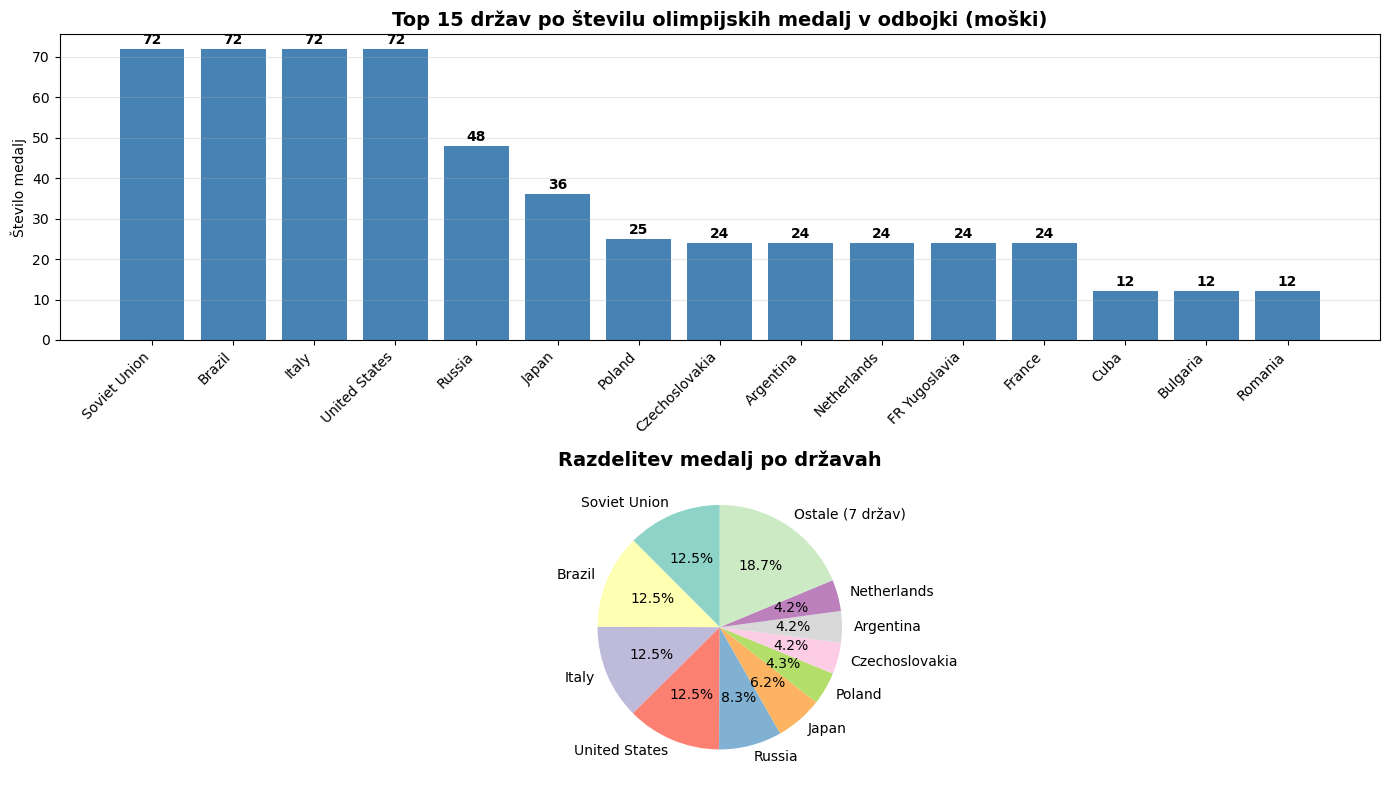


📊 POVZETEK ANALIZE:
   • Največ medalj: Soviet Union (72 medalj)
   • Drugo mesto: Brazil (72 medalj)
   • Tretje mesto: Italy (72 medalj)
   • Top 3 države imajo 216 od 577 medalj (37.4%)


In [3]:
# Grafični prikaz medalj po državah
plt.figure(figsize=(14, 8))

# Stolpčni grafikon za top 15 držav
top_15 = medals_by_country.head(15)
plt.subplot(2, 1, 1)
bars = plt.bar(range(len(top_15)), top_15.values, color='steelblue')
plt.xticks(range(len(top_15)), top_15.index, rotation=45, ha='right')
plt.title('Top 15 držav po številu olimpijskih medalj v odbojki (moški)', fontsize=14, fontweight='bold')
plt.ylabel('Število medalj')
plt.grid(axis='y', alpha=0.3)

# Dodajanje vrednosti na stolpce
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# Tortni diagram za top 10 držav + ostale
plt.subplot(2, 1, 2)
top_10 = medals_by_country.head(10)
others = medals_by_country[10:].sum()

# Pripravi podatke za tortni diagram
pie_data = list(top_10.values) + [others] if others > 0 else list(top_10.values)
pie_labels = list(top_10.index) + [f'Ostale ({len(medals_by_country)-10} držav)'] if others > 0 else list(top_10.index)

colors = plt.cm.Set3(range(len(pie_data)))
plt.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Razdelitev medalj po državah', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Povzetek za uporabnika
print(f"\n📊 POVZETEK ANALIZE:")
print(f"   • Največ medalj: {top_10.index[0]} ({top_10.iloc[0]} medalj)")
print(f"   • Drugo mesto: {top_10.index[1]} ({top_10.iloc[1]} medalj)")
print(f"   • Tretje mesto: {top_10.index[2]} ({top_10.iloc[2]} medalj)")
print(f"   • Top 3 države imajo {top_10.iloc[0:3].sum()} od {medals_by_country.sum()} medalj ({top_10.iloc[0:3].sum()/medals_by_country.sum()*100:.1f}%)")

## Osvojene zlate medalje posameznih držav skozi čas

In [4]:
# Analiza zlatih medalj skozi čas
gold_medals = df[df['medal_type'] == 'gold'].copy()

# Grupiranje po olimpijskih igrah in državah
gold_by_year = gold_medals.groupby(['olympic_year', 'country']).size().reset_index(name='players_count')
gold_winners = gold_medals.groupby('olympic_year')['country'].first().reset_index()

print("=== ZMAGOVALCI ZLATIH MEDALJ PO LETIH ===")
for _, row in gold_winners.iterrows():
    year = row['olympic_year']
    country = row['country']
    player_count = gold_medals[gold_medals['olympic_year'] == year]['player_name'].nunique()
    print(f"{year:<15} {country:<20}")

# Analiza dominance po obdobjih
print("\n=== ANALIZA PREVLADE PO OBDOBJIH ===")
print("Štev. zlatih medalj po državah:")
gold_count_by_country = gold_winners['country'].value_counts()
for country, count in gold_count_by_country.items():
    years = gold_winners[gold_winners['country'] == country]['olympic_year'].tolist()
    years_str = ', '.join(years)
    print(f"{country:<20} {count}x zlata ({years_str})")

=== ZMAGOVALCI ZLATIH MEDALJ PO LETIH ===
1964 Tokyo      Soviet Union        
1968 Mexico City Soviet Union        
1972 Munich     Japan               
1976 Montreal   Poland              
1980 Moscow     Soviet Union        
1984 Los Angeles United States       
1988 Seoul      United States       
1992 Barcelona  Brazil              
1996 Atlanta    Netherlands         
2000 Sydney     FR Yugoslavia       
2004 Athens     Brazil              
2008 Beijing    United States       
2012 London     Russia              
2016 Rio de Janeiro Brazil              
2020 Tokyo      France              
2024 Paris      France              

=== ANALIZA PREVLADE PO OBDOBJIH ===
Štev. zlatih medalj po državah:
Soviet Union         3x zlata (1964 Tokyo, 1968 Mexico City, 1980 Moscow)
United States        3x zlata (1984 Los Angeles, 1988 Seoul, 2008 Beijing)
Brazil               3x zlata (1992 Barcelona, 2004 Athens, 2016 Rio de Janeiro)
France               2x zlata (2020 Tokyo, 2024 Paris)
Japan

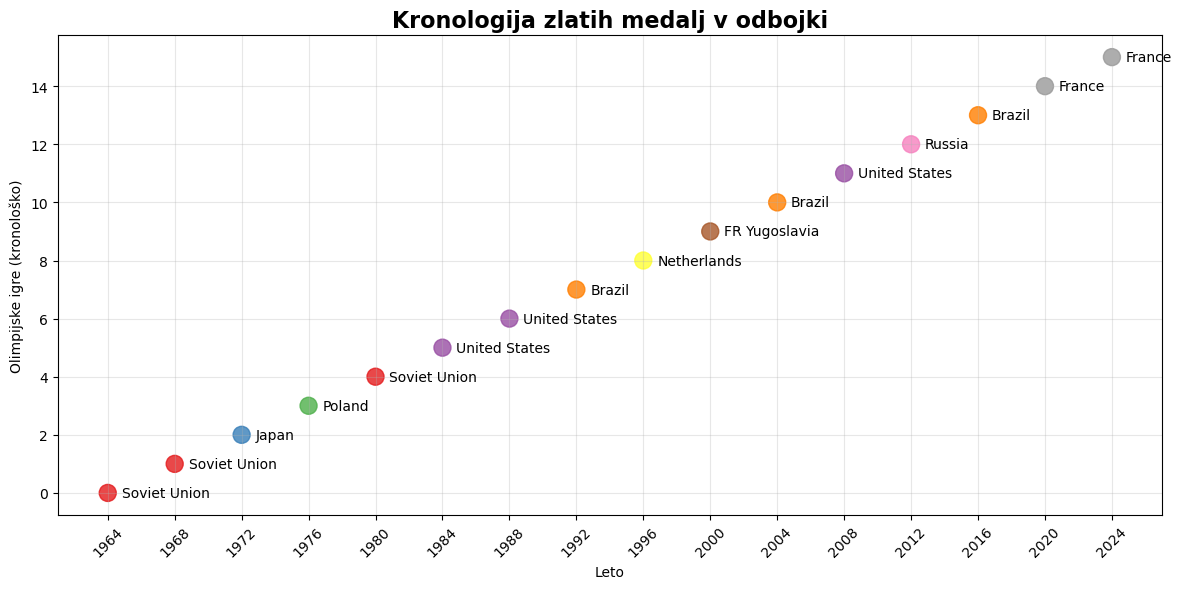

In [7]:
# Vizualizacija dominance skozi čas
plt.figure(figsize=(12, 6))

# Timeline zlatih medalj
years = [year.split()[0] for year in gold_winners['olympic_year']]  # Samo leto
countries = gold_winners['country']

# Kreirajmo barvno shemo za države
unique_countries = countries.unique()
colors_map = plt.cm.Set1(range(len(unique_countries)))
country_colors = {country: colors_map[i] for i, country in enumerate(unique_countries)}

plt.scatter(years, range(len(years)), c=[country_colors[country] for country in countries], s=150, alpha=0.8)
for i, (year, country) in enumerate(zip(years, countries)):
    plt.annotate(country, (year, i), xytext=(10, 0), textcoords='offset points', 
                fontsize=10, ha='left', va='center')

plt.xlabel('Leto')
plt.ylabel('Olimpijske igre (kronološko)')
plt.title('Kronologija zlatih medalj v odbojki', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Igralci z največ zlatimi medaljami

In [6]:
# Analiza igralcev z zlatimi medaljami
gold_players = df[df['medal_type'] == 'gold'].copy()

# Štetje zlatih medalj po igralcih
player_gold_counts = gold_players['player_name'].value_counts()

print("=== VSI IGRALCI Z ZLATIMI MEDALJAMI (razvrščeni po številu medalj) ===")
print(f"Skupno igralcev z zlatimi medaljami: {len(player_gold_counts)}")
print(f"Skupno zlatih medalj: {player_gold_counts.sum()}")
print()

# Prikaz vseh igralcev z zlatimi medaljami
for i, (player, count) in enumerate(player_gold_counts.items(), 1):
    # Poiščimo dodatne informacije o igralcu
    player_data = gold_players[gold_players['player_name'] == player]
    countries = player_data['country'].unique()
    years = player_data['olympic_year'].unique()
    
    # Formatiranje izpisa
    countries_str = ', '.join(countries)
    years_str = ', '.join(sorted(years))
    
    print(f"{i:2d}. {player:<25} {count}x zlata | {countries_str:<20} | {years_str}")

print("\n" + "="*80)

=== VSI IGRALCI Z ZLATIMI MEDALJAMI (razvrščeni po številu medalj) ===
Skupno igralcev z zlatimi medaljami: 172
Skupno zlatih medalj: 192

 1. Ivans Bugajenkovs         2x zlata | Soviet Union         | 1964 Tokyo, 1968 Mexico City
 2. Earvin N'Gapeth           2x zlata | France               | 2020 Tokyo, 2024 Paris
 3. Karch Kiraly              2x zlata | United States        | 1984 Los Angeles, 1988 Seoul
 4. Sérgio Santos             2x zlata | Brazil               | 2004 Athens, 2016 Rio de Janeiro
 5. Craig Buck                2x zlata | United States        | 1984 Los Angeles, 1988 Seoul
 6. Steve Timmons             2x zlata | United States        | 1984 Los Angeles, 1988 Seoul
 7. Giovane Gávio             2x zlata | Brazil               | 1992 Barcelona, 2004 Athens
 8. Maurício Lima             2x zlata | Brazil               | 1992 Barcelona, 2004 Athens
 9. Barthélémy Chinenyeze     2x zlata | France               | 2020 Tokyo, 2024 Paris
10. Jenia Grebennikov         2x z